<h2 style="color:blue;">📌 Data Attribution</h2>

All answers generated in this notebook are based on content retrieved from a curated set of transcript files located in the https://github.com/Azure-Samples/postgreSQL-graphRAG-docker/tree/main/project_folder/data/input. These transcripts are sourced from episodes of the https://www.microsoft.com/en-us/behind-the-tech.

Each response is derived using graphRAG, Cypher query, vector search, or AI agent techniques, and reflects the content of the original podcast transcripts. Please refer to the source folder above for the full context of each episode.

If you use or share this notebook, ensure that proper attribution to the original podcast and transcript sources is maintained.


In [1]:
from IPython.display import display, Markdown

def add_section_title(title, color="black", size="24px"):
    display(Markdown(f"<h2 style='color:{color}; font-size:{size};'>{title}</h2>"))


In [2]:
add_section_title("Step 1: Setup postgres connection", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 1: Setup postgres connection</h2>

In [3]:
import psycopg2
import os

def get_connection():
    host = os.getenv("AGE_HOST") if os.getenv("USE_LOCAL_AGE") == "true" else os.getenv("POSTGRES_HOST")
    port = os.getenv("AGE_PORT") if os.getenv("USE_LOCAL_AGE") == "true" else os.getenv("POSTGRES_PORT")
    user = os.getenv("AGE_USER") if os.getenv("USE_LOCAL_AGE") == "true" else os.getenv("POSTGRES_USER")
    password = os.getenv("AGE_PASSWORD") if os.getenv("USE_LOCAL_AGE") == "true" else os.getenv("POSTGRES_PASSWORD")
    dbname = os.getenv("AGE_DB") if os.getenv("USE_LOCAL_AGE") == "true" else os.getenv("POSTGRES_DB")

    return psycopg2.connect(
        host=host,
        port=port,
        user=user,
        password=password,
        dbname=dbname
    )
"""     
conn = get_connection()
cur = conn.cursor()
cur.close()
conn.close()
"""

'     \nconn = get_connection()\ncur = conn.cursor()\ncur.close()\nconn.close()\n'

In [4]:
add_section_title("Step 2: Check Nodes, Relationship count", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 2: Check Nodes, Relationship count</h2>

In [5]:
conn = get_connection()
cur = conn.cursor()

# Set search path and run a Cypher query
cur.execute("LOAD 'age';")
cur.execute('SET search_path = ag_catalog, "$user", public;')
cur.execute("""
    SELECT * FROM cypher('graphRAG', $$
        MATCH (n) RETURN labels(n), count(n)
    $$) AS (labels agtype, count agtype);
""")


# Print results
for row in cur.fetchall():
    print(row)


('["Entity"]', '437')
('["Document"]', '10')


In [6]:
cur = conn.cursor()

# Set search path and run a Cypher query
cur.execute("LOAD 'age';")
cur.execute('SET search_path = ag_catalog, "$user", public;')
cur.execute("""
    SELECT * FROM cypher('graphRAG', $$
        MATCH ()-[r]->() RETURN type(r), count(r)
    $$) AS (relationship agtype, count agtype);
""")

# Print results
for row in cur.fetchall():
    print(row)


('"RELATED_TO"', '696')


In [7]:
add_section_title("Step 3a: Show entity, relationship properties using Cypher query", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 3a: Show entity, relationship properties using Cypher query</h2>

In [8]:
conn = get_connection()
cur = conn.cursor()
cur.execute("LOAD 'age';")
cur.execute('SET search_path = ag_catalog, "$user", public;')

# List Document Node Properties
cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH (d:Document)
    RETURN keys(d) AS document_properties
    LIMIT 1
$$) AS (document_properties agtype);
""")

for row in cur.fetchall():
    print(row)

# List Entity Node Properties
cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH (e:Entity)
    RETURN keys(e) AS entity_properties
    LIMIT 1
$$) AS (entity_properties agtype);
""")
for row in cur.fetchall():
    print(row)

# List Relationship Properties:    
cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH ()-[r:RELATED_TO]->()
    RETURN DISTINCT keys(r) AS relationship_keys
$$) AS (relationship_keys agtype);
""")


for row in cur.fetchall():
    print(row)

# List a few relationships, see the properties:
cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH ()-[r:RELATED_TO]->()
    WHERE exists(r.source) OR exists(r.target)
    RETURN r.source AS source, r.target AS target, r.description AS description
    LIMIT 5
$$) AS (source text, target text, description text);
""")

for row in cur.fetchall():
    print(row)


('["id", "name", "text", "title", "metadata", "creation_date", "text_unit_ids", "human_readable_id"]',)
('["x", "y", "id", "name", "type", "title", "degree", "frequency", "description", "text_unit_ids", "human_readable_id"]',)
('["id", "source", "target", "weight", "description", "text_unit_ids", "combined_degree", "human_readable_id"]',)
('KEVIN SCOTT', 'DIO GONZALEZ', 'Kevin Scott and Dio Gonzalez are two individuals who share a deep passion for computers and programming, which was inspired by their early experiences with visual and interactive technologies. They recently engaged in a discussion about mixed reality and its applications across various fields, as well as virtual reality, highlighting their shared interest in cutting-edge technology. Kevin Scott interviewed Dio Gonzalez on the *Behind the Tech* podcast, where they explored her work in mixed reality and delved into her personal hobbies. Their conversation underscored their mutual enthusiasm for technological innovation a

In [9]:
add_section_title("Step 3b: Visualize the graph", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 3b: Visualize the graph</h2>

In [12]:
# Make sure pyvis is installed in your Docker container
import psycopg2
from pyvis.network import Network
from IPython.display import IFrame

# Connect to PostgreSQL with AGE
conn = get_connection()
cur = conn.cursor()
cur.execute("LOAD 'age';")
cur.execute('SET search_path = ag_catalog, "$user", public;')

# Query all Document nodes
cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH (d:Document)
    RETURN d.human_readable_id AS id, d.name AS name, d.title AS title,
           d.creation_date AS creation_date
$$) AS (
    id agtype, title agtype, name agtype, creation_date agtype
);
""")
document_nodes = cur.fetchall()
#["id", "name", "text", "title", "metadata", "creation_date", "text_unit_ids", "human_readable_id"]',)

# Query all Entity nodes
cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH (e:Entity)
    RETURN e.human_readable_id AS id, e.title AS title, e.type AS type,
           e.description AS description, e.frequency AS frequency,
           e.degree AS degree, e.x AS x, e.y AS y
$$) AS (
    id agtype, title agtype, type agtype, description agtype,
    frequency agtype, degree agtype, x agtype, y agtype
);
""")
entity_nodes = cur.fetchall()

# Query all RELATED_TO relationships
cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH (a:Entity)-[r:RELATED_TO]->(b:Entity)
    RETURN r.human_readable_id AS id, a.title AS source, b.title AS target,
           r.description AS description, r.weight AS weight,
           r.combined_degree AS combined_degree
$$) AS (
    id agtype, source agtype, target agtype,
    description agtype, weight agtype, combined_degree agtype
);
""")
edges = cur.fetchall()

# Create the Pyvis network
net = Network(height="700px", width="100%", notebook=True, directed=True, cdn_resources='in_line')

# Track node titles
node_titles = set()

# Add Document nodes
for node in document_nodes:
    node_title = node[1]
    node_titles.add(node_title)
    net.add_node(
        node_title,
        label=node_title,
        title=f"Name: {node[2]}<br>Created: {node[3]}",
        shape="dot",
        color="orange"
    )

# Add Entity nodes
for node in entity_nodes:
    node_title = node[1]
    node_titles.add(node_title)
    net.add_node(
        node_title,
        label=node_title,
        title=f"Type: {node[2]}<br>Description: {node[3]}<br>Freq: {node[4]}<br>Degree: {node[5]}",
        shape="dot",
        color="lightblue"
    )

# Add edges only if both source and target titles exist
for edge in edges:
    source = edge[1]  # source title
    target = edge[2]  # target title
    if source in node_titles and target in node_titles:
        net.add_edge(
            source,
            target,
            title=f"{edge[3]}<br>Weight: {edge[4]}<br>Combined Degree: {edge[5]}",
            value=edge[4]
        )
    else:
        print(f"Skipping edge from '{source}' to '{target}' — node missing.")

# Save and open the graph
net.show("graphRAG_visualization.html", notebook=True)

# Embed the HTML file in the notebook output
IFrame("graphRAG_visualization.html", width="100%", height="700px")


graphRAG_visualization.html


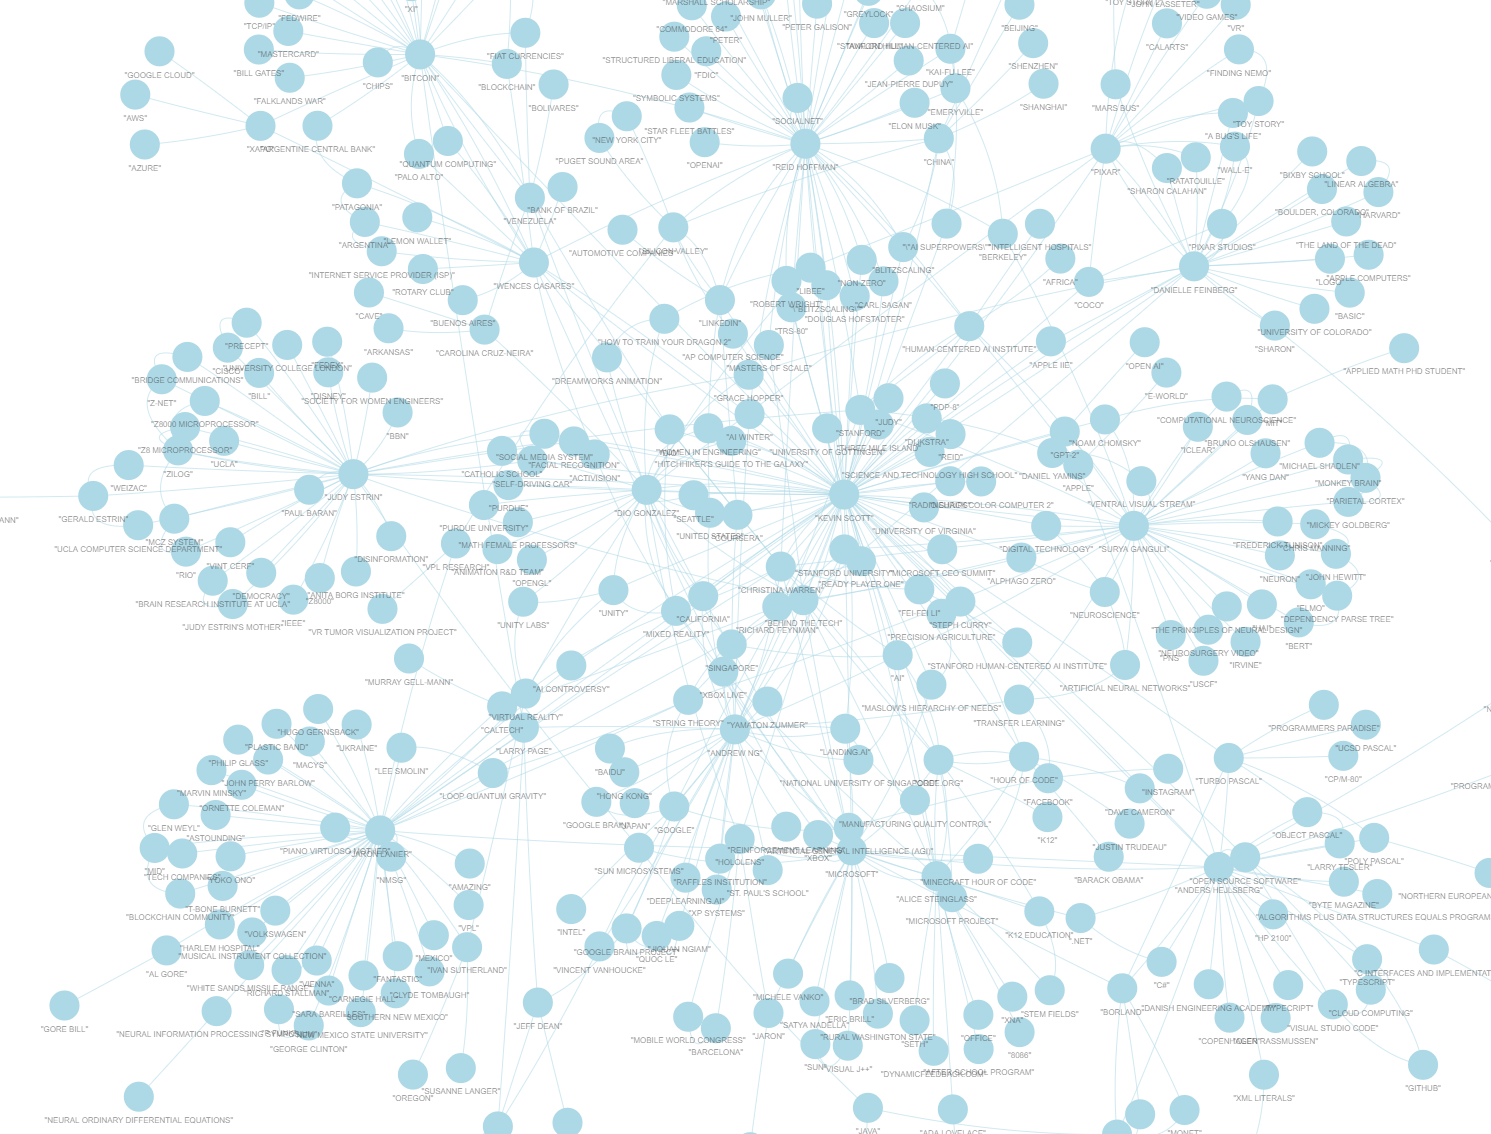

In [11]:
conn = get_connection()
cur = conn.cursor()

cur.execute("LOAD 'age';")
cur.execute('SET search_path = ag_catalog, "$user", public;')
cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH (a:Entity)-[r]->(b:Entity)
    RETURN 
        r.human_readable_id AS id,
        a.title AS source,
        b.title AS target,
        r.description AS description,
        r.weight AS weight,
        r.combined_degree AS combined_degree
    LIMIT 20
$$) AS (
    id agtype, source agtype, target agtype,
    description agtype, weight agtype, combined_degree agtype
);

""")
for row in cur.fetchall():
    print(row)


('"0"', '"DIO GONZALEZ"', '"MICROSOFT"', '"Dio Gonzalez is a principal software architect at Microsoft, having joined the company in December 2017 as part of Central Engineering. He is deeply inspired by Microsoft\'s advancements in mixed reality technologies and actively contributes to the development of mixed reality tools. His work focuses on enabling users to create games and immersive worlds, showcasing his commitment to innovation in this cutting-edge field."', '"26.0"', '"54"')
('"1"', '"DIO GONZALEZ"', '"PURDUE UNIVERSITY"', '"Dio Gonzalez attended Purdue University, where he focused on virtual reality and played a pivotal role in establishing the university\'s first virtual reality facility. His contributions to Purdue University highlight his expertise and dedication to advancing immersive technologies."', '"17.0"', '"28"')
('"2"', '"DIO GONZALEZ"', '"PIXAR"', '"Dio Gonzalez worked at Pixar earlier in her career as a character animation engineer. During her time at the compan

In [12]:
conn = get_connection()
cur = conn.cursor()

cur.execute("LOAD 'age';")
cur.execute('SET search_path = ag_catalog, "$user", public;')
cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH (n:Entity)
    RETURN 
        n.human_readable_id AS id,
        n.title AS title,
        n.type AS type,
        n.description AS description,
        n.frequency AS frequency,
        n.degree AS degree,
        n.x AS x,
        n.y AS y
    LIMIT 20
$$) AS (
    id agtype, title agtype, type agtype, description agtype,
    frequency agtype, degree agtype, x agtype, y agtype
);


""")
for row in cur.fetchall():
    print(row)


('"0"', '"DIO GONZALEZ"', '"PERSON"', '"Dio Gonzalez is a Venezuelan computer scientist, software architect, and technologist with expertise in virtual reality, mixed reality, computer graphics, and animation. As a Latina, immigrant, and non-native English speaker, she has overcome significant challenges, including poor standardized test results and bullying, to establish herself as a prominent figure in technology. She is passionate about increasing diversity in engineering and technology fields, particularly for women and underrepresented communities, and actively advocates for education, role models, and collaboration with male allies to support these efforts.\\n\\nDio Gonzalez has an impressive academic and professional background. She studied at Purdue University, where she helped set up its first virtual reality facility, and later taught games programming in Singapore. Her career spans work in academia and industry, including roles at Pixar, DreamWorks Animation, Unity Labs, and

In [13]:
add_section_title("Step 4: Multi-hop Cypher query", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 4: Multi-hop Cypher query</h2>

In [14]:
"""
A multi-hop Cypher query

Original .txt input:
“Next time on Behind the Tech, we'll hear from Alice Steinglass who heads Code.org. We'll hear about how she's working to make sure every kid has the opportunity to take computer science classes in school.”

multi-hop query example:

Kevin mentioned Alice,
Alice is connected to Code.org,
And the relationship description gives a rich summary of what Code.org does and Alice’s role in it.
"""

conn = get_connection()
cur = conn.cursor()

# Set search path and run a Cypher query
cur.execute("LOAD 'age';")
cur.execute('SET search_path = ag_catalog, "$user", public;')

cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH (kevin:Entity {title: 'KEVIN SCOTT'})-[:RELATED_TO]->(alice:Entity {title: 'ALICE STEINGLASS'})
          -[r:RELATED_TO]->(org:Entity)
    WHERE toLower(r.description) CONTAINS 'code.org'
    RETURN kevin.title AS source,
           alice.title AS intermediate,
           org.title AS target,
           r.description AS relationship_description
$$) AS (source text, intermediate text, target text, relationship_description text);
""")


for row in cur.fetchall():
    print(row)



('KEVIN SCOTT', 'ALICE STEINGLASS', 'KEVIN SCOTT', 'Alice Steinglass and Kevin Scott are collaborators who share a strong commitment to making computer science accessible to children and addressing gender stereotypes in computer science education. Their shared mission has been a focal point of discussions, including their appearance on a podcast where they explored strategies to promote inclusivity in the field. Kevin Scott also interviewed Alice Steinglass about her career journey and her impactful work at Code.org, highlighting her contributions to advancing computer science education and fostering diversity in technology.')
('KEVIN SCOTT', 'ALICE STEINGLASS', 'CODE.ORG', "Alice Steinglass is the President of Code.org, an organization dedicated to expanding access to computer science education globally. She leads Code.org's mission to teach computer science, promote diversity in technology, and ensure its integration into schools. Under her leadership, Code.org runs impactful initiat

In [15]:
"""
A multi-hop Cypher query

Original .txt input:
“Next time on Behind the Tech, we'll hear from Alice Steinglass who heads Code.org. We'll hear about how she's working to make sure every kid has the opportunity to take computer science classes in school.”

Run a query:
"Who did KEVIN SCOTT mention that leads a company helping kids learn computer science?”
"""
conn = get_connection()
cur = conn.cursor()

# Set search path and run a Cypher query
cur.execute("LOAD 'age';")
cur.execute('SET search_path = ag_catalog, "$user", public;')

cur.execute("""
SELECT * FROM cypher('graphRAG', $$
    MATCH (kevin:Entity {title: 'KEVIN SCOTT'})-[:RELATED_TO]->(person:Entity)
          -[r:RELATED_TO]->(company:Entity)
    WHERE toLower(r.description) CONTAINS 'computer science'
       OR toLower(r.description) CONTAINS 'education'
       OR toLower(r.description) CONTAINS 'kids'
    RETURN person.title AS mentioned_person,
           company.title AS organization,
           r.description AS relationship_description
$$) AS (mentioned_person text, organization text, relationship_description text);
""")

for row in cur.fetchall():
    print(row)
"""    
This query will return:

The person Kevin mentioned.
The company they’re connected to.
A description of that connection that includes educational or youth-oriented language.
"""


('DIO GONZALEZ', 'VENEZUELA', "Dio Gonzalez is originally from Venezuela, where she grew up and developed a passion for roller skating. During her time in Venezuela, she completed her undergraduate studies and first cultivated an interest in computer science. Her academic journey included learning about Carolina Cruz-Neira's contributions to virtual reality during computer graphics classes, which further deepened her engagement with the field. Additionally, Dio Gonzalez worked in Venezuela, where she faced the challenges of being a minority in technology, an experience that shaped her perspective and resilience.")
('DIO GONZALEZ', 'SINGAPORE', "Dio Gonzalez, after completing his master's degree, pursued a career in Singapore where he taught games programming. During his time in Singapore, he also navigated the challenges of being a minority in the technology industry, gaining valuable insights and experiences in both education and professional environments.")
('DIO GONZALEZ', 'UNITED S

'    \nThis query will return:\n\nThe person Kevin mentioned.\nThe company they’re connected to.\nA description of that connection that includes educational or youth-oriented language.\n'

In [16]:
add_section_title("Step 5: graphRAG output checking", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 5: graphRAG output checking</h2>

In [17]:
import pandas as pd
import xml.etree.ElementTree as ET

# Count nodes in graph.graphml
graphml_path = "/app/graphrag-folder/output/graph.graphml"
tree = ET.parse(graphml_path)
root = tree.getroot()
graphml_nodes = len(root.findall(".//{http://graphml.graphdrawing.org/xmlns}node"))
print(f"Number of nodes in graph.graphml: {graphml_nodes}")

# Count rows in text_units.parquet
text_units_path = "/app/graphrag-folder/output/text_units.parquet"
text_units_df = pd.read_parquet(text_units_path)
print(f"Number of rows in text_units.parquet: {len(text_units_df)}")

# Count rows in entities.parquet
entities_path = "/app/graphrag-folder/output/entities.parquet"
entities_df = pd.read_parquet(entities_path)
print(f"Number of rows in entities.parquet: {len(entities_df)}")


Number of nodes in graph.graphml: 437
Number of rows in text_units.parquet: 119
Number of rows in entities.parquet: 437


In [18]:
import pandas as pd

files = [
    "communities.parquet",
    "community_reports.parquet",
    "documents.parquet",
    "embeddings.community.full_content.parquet",
    "embeddings.entity.description.parquet",
    "embeddings.text_unit.text.parquet",
    "relationships.parquet",
    "entities.parquet"
]

for file in files:
    try:
        df = pd.read_parquet(f"/app/graphrag-folder/output/{file}")
        print(f"{file}: {len(df)} rows")
    except Exception as e:
        print(f"Error reading {file}: {e}")


communities.parquet: 95 rows
community_reports.parquet: 95 rows
documents.parquet: 10 rows
embeddings.community.full_content.parquet: 95 rows
embeddings.entity.description.parquet: 437 rows
embeddings.text_unit.text.parquet: 119 rows
relationships.parquet: 696 rows
entities.parquet: 437 rows


In [19]:
import os

import pandas as pd
import tiktoken

from graphrag.query.context_builder.entity_extraction import EntityVectorStoreKey
from graphrag.query.indexer_adapters import (
    read_indexer_covariates,
    read_indexer_entities,
    read_indexer_relationships,
    read_indexer_reports,
    read_indexer_text_units,
)
from graphrag.query.question_gen.local_gen import LocalQuestionGen
from graphrag.query.structured_search.local_search.mixed_context import (
    LocalSearchMixedContext,
)
from graphrag.query.structured_search.local_search.search import LocalSearch
from graphrag.vector_stores.lancedb import LanceDBVectorStore

In [20]:
INPUT_DIR = "/app/graphrag-folder/output/"
LANCEDB_URI = f"{INPUT_DIR}/lancedb"

COMMUNITY_REPORT_TABLE = "community_reports"
ENTITY_TABLE = "entities"
COMMUNITY_TABLE = "communities"
RELATIONSHIP_TABLE = "relationships"
TEXT_UNIT_TABLE = "text_units"
COMMUNITY_LEVEL = 2


In [21]:
# read nodes table to get community and degree data
entity_df = pd.read_parquet(f"{INPUT_DIR}/{ENTITY_TABLE}.parquet")
community_df = pd.read_parquet(f"{INPUT_DIR}/{COMMUNITY_TABLE}.parquet")

entities = read_indexer_entities(entity_df, community_df, COMMUNITY_LEVEL)

# load description embeddings to an in-memory lancedb vectorstore
# to connect to a remote db, specify url and port values.
description_embedding_store = LanceDBVectorStore(
    collection_name="default-entity-description",
)
description_embedding_store.connect(db_uri=LANCEDB_URI)

print(f"Entity count: {len(entity_df)}")
entity_df.head()

Entity count: 437


,id,human_readable_id,title,type,description,text_unit_ids,frequency,degree,x,y
0,2f1d0b2f-7b7f-49eb-8e8f-e0789ebe35cf,0,DIO GONZALEZ,PERSON,Dio Gonzalez is a Venezuelan computer scientis...,[5c537c55a260fcdf05e097fa59681363520e45ab59f39...,11,27,0,0
1,9a606881-8ec5-484d-a87e-66dcd26a34cd,1,KEVIN SCOTT,PERSON,"Kevin Scott is a multifaceted technologist, ex...",[5c537c55a260fcdf05e097fa59681363520e45ab59f39...,112,72,0,0
2,18ca0973-1f45-43fe-a95c-0a5b78d40bb2,2,CHRISTINA WARREN,PERSON,Christina Warren is a Senior Cloud Developer A...,[5c537c55a260fcdf05e097fa59681363520e45ab59f39...,26,14,0,0
3,23cd9dbc-6b09-4f07-9960-8fba9b3f542c,3,MICROSOFT,ORGANIZATION,Microsoft is a global technology company speci...,[5c537c55a260fcdf05e097fa59681363520e45ab59f39...,22,27,0,0
4,d8958257-cda9-4be0-8972-0e950b4af1d9,4,PURDUE UNIVERSITY,ORGANIZATION,Purdue University is a prominent educational i...,[5c537c55a260fcdf05e097fa59681363520e45ab59f39...,2,1,0,0


In [22]:
relationship_df = pd.read_parquet(f"{INPUT_DIR}/{RELATIONSHIP_TABLE}.parquet")
relationships = read_indexer_relationships(relationship_df)

print(f"Relationship count: {len(relationship_df)}")
relationship_df.head()

Relationship count: 696


,id,human_readable_id,source,target,description,weight,combined_degree,text_unit_ids
0,5f19d78e-719e-4d70-9dc7-c5fb4a2c6324,0,DIO GONZALEZ,MICROSOFT,Dio Gonzalez is a principal software architect...,26.0,54,[5c537c55a260fcdf05e097fa59681363520e45ab59f39...
1,522713f8-22b2-47c2-bb09-00aa1de7f830,1,DIO GONZALEZ,PURDUE UNIVERSITY,"Dio Gonzalez attended Purdue University, where...",17.0,28,[5c537c55a260fcdf05e097fa59681363520e45ab59f39...
2,c4057089-036e-4f41-b996-be1d777a7ab9,2,DIO GONZALEZ,PIXAR,Dio Gonzalez worked at Pixar earlier in her ca...,22.0,43,[5c537c55a260fcdf05e097fa59681363520e45ab59f39...
3,c6e59dc5-0028-44b8-8453-5b69b3d6cdac,3,DIO GONZALEZ,DREAMWORKS ANIMATION,Dio Gonzalez is a professional who worked at D...,15.0,29,[5c537c55a260fcdf05e097fa59681363520e45ab59f39...
4,520bb1a2-2c14-4ef0-95e1-783b0845473e,4,DIO GONZALEZ,UNITY LABS,Dio Gonzalez is a skilled professional who pre...,17.0,30,[5c537c55a260fcdf05e097fa59681363520e45ab59f39...


In [23]:
report_df = pd.read_parquet(f"{INPUT_DIR}/{COMMUNITY_REPORT_TABLE}.parquet")
reports = read_indexer_reports(report_df, community_df, COMMUNITY_LEVEL)

print(f"Report records: {len(report_df)}")
report_df.head()

Report records: 95


,id,human_readable_id,community,level,parent,children,title,summary,full_content,rank,rating_explanation,findings,full_content_json,period,size
0,bdd5ee89cbe045c08f434b3dbf60ec62,91,91,3,70,[],LinkedIn and Automotive Companies Hiring Trends,"This community centers around LinkedIn, a prof...",# LinkedIn and Automotive Companies Hiring Tre...,7.5,The impact severity rating is high due to Link...,"[{'explanation': 'LinkedIn, co-founded by Reid...","{\n ""title"": ""LinkedIn and Automotive Compa...",2025-06-13,2
1,862651b14dd84c619b4a5650b7b98005,92,92,3,70,[],Kevin Scott and AI Community,"The community centers around Kevin Scott, a pr...",# Kevin Scott and AI Community\n\nThe communit...,8.5,The impact severity rating is high due to Kevi...,[{'explanation': 'Kevin Scott is a central fig...,"{\n ""title"": ""Kevin Scott and AI Community""...",2025-06-13,18
2,8c5054a230b64da4b388a26597f62ff6,93,93,3,78,[],Bitcoin and Fiat Currencies in Turkey,This community centers around the relationship...,# Bitcoin and Fiat Currencies in Turkey\n\nThi...,7.5,The impact severity rating is high due to the ...,[{'explanation': 'Bitcoin is highlighted as a ...,"{\n ""title"": ""Bitcoin and Fiat Currencies i...",2025-06-13,2
3,c80ab5a1d70e434a89163710f3f84517,94,94,3,78,[],Bitcoin and Blockchain Ecosystem,"The community revolves around Bitcoin, a decen...",# Bitcoin and Blockchain Ecosystem\n\nThe comm...,8.5,The impact severity rating is high due to Bitc...,[{'explanation': 'Bitcoin is a decentralized d...,"{\n ""title"": ""Bitcoin and Blockchain Ecosys...",2025-06-13,18
4,ae2d2cebaf8344ab857081185d780b0b,69,69,2,18,[],Behind the Tech Community Featuring Kevin Scot...,The community centers around the 'Behind the T...,# Behind the Tech Community Featuring Kevin Sc...,7.5,The impact severity rating is high due to the ...,[{'explanation': 'Kevin Scott is the host of t...,"{\n ""title"": ""Behind the Tech Community Fea...",2025-06-13,2


In [24]:
text_unit_df = pd.read_parquet(f"{INPUT_DIR}/{TEXT_UNIT_TABLE}.parquet")
text_units = read_indexer_text_units(text_unit_df)

print(f"Text unit records: {len(text_unit_df)}")
text_unit_df.head()

Text unit records: 119


,id,human_readable_id,text,n_tokens,document_ids,entity_ids,relationship_ids,covariate_ids
0,5c537c55a260fcdf05e097fa59681363520e45ab59f392...,1,DIO GONZALEZ: (VOICEOVER) And so they made us ...,1200,[25590c2303379ea1ba9fbcab0dc8664f2f943864091ec...,"[2f1d0b2f-7b7f-49eb-8e8f-e0789ebe35cf, 9a60688...","[5f19d78e-719e-4d70-9dc7-c5fb4a2c6324, 522713f...",[]
1,678f6d9f75e36a229f89e8d1b4bc035fd5acc38d0d8099...,2,"they explained us how to do it. Like, you fi...",1200,[25590c2303379ea1ba9fbcab0dc8664f2f943864091ec...,"[2f1d0b2f-7b7f-49eb-8e8f-e0789ebe35cf, 9a60688...","[522713f8-22b2-47c2-bb09-00aa1de7f830, dae6954...",[]
2,2b3ea036c5954b0fa0198abe95da83efedf0d689a8b6a6...,3,"thesis. At that time, there was no Oculus, r...",1200,[25590c2303379ea1ba9fbcab0dc8664f2f943864091ec...,"[2f1d0b2f-7b7f-49eb-8e8f-e0789ebe35cf, 9a60688...","[c4057089-036e-4f41-b996-be1d777a7ab9, dae6954...",[]
3,e2b1c2c2daafc008f6cf43844a96b7fc7f5ed1eb3920b5...,4,"hey, grand mommy. (Laughter.) \n\nKEVIN SCOT...",1200,[25590c2303379ea1ba9fbcab0dc8664f2f943864091ec...,"[2f1d0b2f-7b7f-49eb-8e8f-e0789ebe35cf, 9a60688...","[c4057089-036e-4f41-b996-be1d777a7ab9, c6e59dc...",[]
4,d07370b5bb40e78843e93c1aacb8520e75138bd0ab9fed...,5,"the engineer and I know how it was done, like...",1200,[25590c2303379ea1ba9fbcab0dc8664f2f943864091ec...,"[2f1d0b2f-7b7f-49eb-8e8f-e0789ebe35cf, 9a60688...","[520bb1a2-2c14-4ef0-95e1-783b0845473e, 3505575...",[]


In [25]:
add_section_title("Step 6: graphRAG LocalSearch", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 6: graphRAG LocalSearch</h2>

In [26]:
import os
from graphrag.config.enums import ModelType
from graphrag.config.models.language_model_config import LanguageModelConfig
from graphrag.language_model.manager import ModelManager

# Optional: load .env if not already loaded
from dotenv import load_dotenv
load_dotenv()  # only needed if you're running outside Docker or .env isn't auto-loaded

# Read from environment
api_key = os.environ["AOAI_API_KEY"]
llm_model = os.environ["AOAI_LLM_MODEL"]
llm_api_version = os.environ["AOAI_LLM_API_VERSION"].strip('"')
llm_deployment = os.environ["AOAI_LLM_DEPLOYMENT"]

embedding_model = os.environ["AOAI_EMBEDDING_MODEL"]
embedding_api_version = os.environ["AOAI_EMBEDDING_API_VERSION"].strip('"')
embedding_deployment = os.environ["AOAI_EMBEDDING_DEPLOYMENT"]

# Shared AOAI base
api_base = "https://graphrag-eastus2.openai.azure.com"

# Chat model config
chat_config = LanguageModelConfig(
    api_key=api_key,
    type=ModelType.AzureOpenAIChat,
    model=llm_model,
    api_base=api_base,
    api_version=llm_api_version,
    deployment_name=llm_deployment,
    max_retries=5,
)

token_encoder = tiktoken.encoding_for_model(llm_model)

# Embedding model config
embedding_config = LanguageModelConfig(
    api_key=api_key,
    type=ModelType.AzureOpenAIEmbedding,
    model=embedding_model,
    api_base=api_base,
    api_version=embedding_api_version,
    deployment_name=embedding_deployment,
    max_retries=5,
)

# Initialize models
chat_model = ModelManager().get_or_create_chat_model(
    name="local_search",
    model_type=chat_config.type,
    config=chat_config,
)

text_embedder = ModelManager().get_or_create_embedding_model(
    name="local_search_embedding",
    model_type=embedding_config.type,
    config=embedding_config,
)


In [27]:
context_builder = LocalSearchMixedContext(
    community_reports=reports,
    text_units=text_units,
    entities=entities,
    relationships=relationships,
    # if you did not run covariates during indexing, set this to None
    covariates=None,
    entity_text_embeddings=description_embedding_store,
    embedding_vectorstore_key=EntityVectorStoreKey.ID,  # if the vectorstore uses entity title as ids, set this to EntityVectorStoreKey.TITLE
    text_embedder=text_embedder,
    token_encoder=token_encoder,
)

In [28]:
# text_unit_prop: proportion of context window dedicated to related text units
# community_prop: proportion of context window dedicated to community reports.
# The remaining proportion is dedicated to entities and relationships. Sum of text_unit_prop and community_prop should be <= 1
# conversation_history_max_turns: maximum number of turns to include in the conversation history.
# conversation_history_user_turns_only: if True, only include user queries in the conversation history.
# top_k_mapped_entities: number of related entities to retrieve from the entity description embedding store.
# top_k_relationships: control the number of out-of-network relationships to pull into the context window.
# include_entity_rank: if True, include the entity rank in the entity table in the context window. Default entity rank = node degree.
# include_relationship_weight: if True, include the relationship weight in the context window.
# include_community_rank: if True, include the community rank in the context window.
# return_candidate_context: if True, return a set of dataframes containing all candidate entity/relationship/covariate records that
# could be relevant. Note that not all of these records will be included in the context window. The "in_context" column in these
# dataframes indicates whether the record is included in the context window.
# max_tokens: maximum number of tokens to use for the context window.


local_context_params = {
    "text_unit_prop": 0.5,
    "community_prop": 0.1,
    "conversation_history_max_turns": 5,
    "conversation_history_user_turns_only": True,
    "top_k_mapped_entities": 10,
    "top_k_relationships": 10,
    "include_entity_rank": True,
    "include_relationship_weight": True,
    "include_community_rank": False,
    "return_candidate_context": False,
    "embedding_vectorstore_key": EntityVectorStoreKey.ID,  # set this to EntityVectorStoreKey.TITLE if the vectorstore uses entity title as ids
    "max_tokens": 12_000,  # change this based on the token limit you have on your model (if you are using a model with 8k limit, a good setting could be 5000)
}

model_params = {
    "max_tokens": 2_000,  # change this based on the token limit you have on your model (if you are using a model with 8k limit, a good setting could be 1000=1500)
    "temperature": 0.0,
}

In [29]:
search_engine = LocalSearch(
    model=chat_model,
    context_builder=context_builder,
    token_encoder=token_encoder,
    model_params=model_params,
    context_builder_params=local_context_params,
    response_type="multiple paragraphs",  # free form text describing the response type and format, can be anything, e.g. prioritized list, single paragraph, multiple paragraphs, multiple-page report
)

In [30]:
add_section_title("Note: include_community_rank=False, community_prop=0.1", color="blue", size="14px")

<h2 style='color:blue; font-size:14px;'>Note: include_community_rank=False, community_prop=0.1</h2>

In [31]:
question = "Who is Alice Seinglass?"
result = await search_engine.search(question)
print(result.response)

### Who is Alice Steinglass?

Alice Steinglass is a prominent computer scientist, technology professional, and advocate for computer science education. Her journey into the tech industry began during her senior year of high school, when she discovered her passion for computer science. She pursued this interest by majoring in Computer Science in college, where she also founded her first startup, **Dynamicfeedback.com**, which focused on workplace improvement through 360-degree surveys [Data: Entities (88, 419); Relationships (663)].

Steinglass has had a diverse career, including significant contributions at Microsoft, where she worked on the development of the first version of **Xbox** and **Xbox Live**, focusing on high-score systems and APIs. She later explored enterprise software by working on **Microsoft Office** and **Microsoft Project**, showcasing her versatility in adapting to different technological domains. She also contributed to the development of **XNA**, a set of tools fo

In [32]:
result.context_data["entities"].head()

,id,entity,description,number of relationships,in_context
0,88,ALICE STEINGLASS,Alice Steinglass is a prominent computer scien...,17,True
1,417,SETH,"Seth is Alice Steinglass's younger brother, wh...",1,True
2,419,DYNAMICFEEDBACK.COM,Dynamicfeedback.com was a startup founded by A...,1,True
3,418,8086,The 8086 is an older computer model that Alice...,1,True
4,422,XNA,XNA is a set of tools and APIs for game develo...,1,True


In [33]:
result.context_data["relationships"].head()

,id,source,target,description,weight,links,in_context
0,661,ALICE STEINGLASS,SETH,Alice Steinglass created a humorous program ta...,7.0,1,True
1,662,ALICE STEINGLASS,8086,Alice Steinglass used and programmed an 8086 c...,6.0,1,True
2,663,ALICE STEINGLASS,DYNAMICFEEDBACK.COM,Alice Steinglass founded dynamicfeedback.com a...,8.0,1,True
3,671,ALICE STEINGLASS,XNA,Alice Steinglass contributed to the developmen...,6.0,1,True
4,672,ALICE STEINGLASS,OFFICE,Alice Steinglass worked on Microsoft Office to...,6.0,1,True


In [34]:
question = "Who did KEVIN SCOTT mention that leads a company helping kids learn computer science?"
result = await search_engine.search(question)
print(result.response)

Kevin Scott mentioned **Alice Steinglass**, who is the President of **Code.org**, a global organization dedicated to expanding computer science education for K-12 students. Under her leadership, Code.org develops curriculum, tools, and software for schools, provides professional development for teachers, and runs the widely recognized **Hour of Code** initiative, which has introduced millions of students to computer science concepts [Data: Entities (87, 88); Sources (31)]. 

Alice Steinglass is a passionate advocate for early computer science education, emphasizing its importance in elementary schools and its role in fostering diversity in STEM fields. She actively promotes gender equality in computer science education and works to create inclusive environments for young learners [Data: Entities (88)].


In [35]:
add_section_title("Note: include_community_rank=True, community_prop=0.8", color="blue", size="14px")

<h2 style='color:blue; font-size:14px;'>Note: include_community_rank=True, community_prop=0.8</h2>

In [36]:
local_context_params = {
    "text_unit_prop": 0.2,
    "community_prop": 0.8,   # increased
    "conversation_history_max_turns": 5,
    "conversation_history_user_turns_only": True,
    "top_k_mapped_entities": 15,  # Increased
    "top_k_relationships": 15,  # Increased
    "include_entity_rank": True,
    "include_relationship_weight": True,
    "include_community_rank": True,    # updated to True
    "return_candidate_context": True,  # updated to True
    "embedding_vectorstore_key": EntityVectorStoreKey.ID,  # set this to EntityVectorStoreKey.TITLE if the vectorstore uses entity title as ids
    "max_tokens": 12_000,  # change this based on the token limit you have on your model (if you are using a model with 8k limit, a good setting could be 5000)
}

model_params = {
    "max_tokens": 2_000,  # change this based on the token limit you have on your model (if you are using a model with 8k limit, a good setting could be 1000=1500)
    "temperature": 0.0,
}

In [37]:
search_engine = LocalSearch(
    model=chat_model,
    context_builder=context_builder,
    token_encoder=token_encoder,
    model_params=model_params,
    context_builder_params=local_context_params,
    response_type="multiple paragraphs",  # free form text describing the response type and format, can be anything, e.g. prioritized list, single paragraph, multiple paragraphs, multiple-page report
)

In [38]:
question = "Who did KEVIN SCOTT mention that leads a company helping kids learn computer science?"
result = await search_engine.search(question)
print(result.response)

Kevin Scott mentioned **Alice Steinglass**, the President of **Code.org**, as a leader in promoting computer science education for children. Code.org is a nonprofit organization dedicated to expanding access to computer science education globally, particularly in K-12 schools. Under Alice Steinglass's leadership, Code.org has spearheaded initiatives like the **Hour of Code**, which introduces millions of students to coding and computer science concepts [Data: Reports (1, 19); Entities (87, 88); Relationships (144, 157, 685, +more)].

Alice Steinglass is also recognized for her advocacy for diversity in STEM fields, focusing on increasing participation among underrepresented minorities and women. Her efforts have been instrumental in shaping Code.org's mission to make computer science accessible to students worldwide [Data: Reports (1, 19); Entities (88); Relationships (157, 677, 685, +more)].


In [39]:
add_section_title("Note: changed the word 'leads' to 'related to'", color="blue", size="14px")

<h2 style='color:blue; font-size:14px;'>Note: changed the word 'leads' to 'related to'</h2>

In [40]:
question = "Who did KEVIN SCOTT mention that is related to computer science, education, or kids?"
result = await search_engine.search(question)
print(result.response)

Kevin Scott mentioned several individuals and organizations related to computer science, education, and initiatives for children. Below is a detailed breakdown:

---

### **Alice Steinglass and Code.org**
Alice Steinglass, the President of Code.org, is a prominent figure in promoting computer science education, particularly for children in K-12 schools. Code.org is widely recognized for its Hour of Code initiative, which introduces millions of students to coding and computer science concepts. The organization emphasizes diversity in STEM fields, advocating for underrepresented minorities and women to increase participation in technology. Kevin Scott's support for Code.org aligns with his broader commitment to education and diversity in technology [Data: Reports (1, 18, 70)].

---

### **Hour of Code Initiative**
The Hour of Code, organized by Code.org, is a global movement designed to introduce students to computer science through engaging, one-hour coding activities. This initiative h

In [41]:
add_section_title("Note: check max community level", color="blue", size="14px")

<h2 style='color:blue; font-size:14px;'>Note: check max community level</h2>

In [42]:
# Know what's the max community level
print(community_df["level"].max())


3


In [43]:
add_section_title("Step 7: graphRAG GlobalSearch", color="blue", size="28px")


<h2 style='color:blue; font-size:28px;'>Step 7: graphRAG GlobalSearch</h2>

In [44]:
import os

import pandas as pd
import tiktoken

from graphrag.config.enums import ModelType
from graphrag.config.models.language_model_config import LanguageModelConfig
from graphrag.language_model.manager import ModelManager
from graphrag.query.indexer_adapters import (
    read_indexer_communities,
    read_indexer_entities,
    read_indexer_reports,
)
from graphrag.query.structured_search.global_search.community_context import (
    GlobalCommunityContext,
)
from graphrag.query.structured_search.global_search.search import GlobalSearch

In [45]:

api_key = os.environ["AOAI_API_KEY"]
api_base = os.environ["AOAI_API_BASE"]
api_version = os.environ["AOAI_LLM_API_VERSION"]
llm_model = os.environ["AOAI_LLM_MODEL"]
llm_deployment = os.environ["AOAI_LLM_DEPLOYMENT"]

config = LanguageModelConfig(
    api_key=api_key,
    api_base=api_base,
    api_version=api_version,
    deployment_name=llm_deployment,
    type=ModelType.AzureOpenAIChat,
    model=llm_model,
    max_retries=5,
)
model = ModelManager().get_or_create_chat_model(
    name="global_search",
    model_type=ModelType.AzureOpenAIChat,
    config=config,
)

token_encoder = tiktoken.encoding_for_model(llm_model)

In [46]:
from dotenv import load_dotenv
load_dotenv()  # only needed if you're running outside Docker or .env isn't auto-loaded

# Read from environment
api_key = os.environ["AOAI_API_KEY"]
llm_model = os.environ["AOAI_LLM_MODEL"]
llm_api_version = os.environ["AOAI_LLM_API_VERSION"].strip('"')
llm_deployment = os.environ["AOAI_LLM_DEPLOYMENT"]

embedding_model = os.environ["AOAI_EMBEDDING_MODEL"]
embedding_api_version = os.environ["AOAI_EMBEDDING_API_VERSION"].strip('"')
embedding_deployment = os.environ["AOAI_EMBEDDING_DEPLOYMENT"]

# Shared AOAI base
api_base = "https://graphrag-eastus2.openai.azure.com"

# Chat model config
chat_config = LanguageModelConfig(
    api_key=api_key,
    type=ModelType.AzureOpenAIChat,
    model=llm_model,
    api_base=api_base,
    api_version=llm_api_version,
    deployment_name=llm_deployment,
    max_retries=5,
)

token_encoder = tiktoken.encoding_for_model(llm_model)

# Embedding model config
embedding_config = LanguageModelConfig(
    api_key=api_key,
    type=ModelType.AzureOpenAIEmbedding,
    model=embedding_model,
    api_base=api_base,
    api_version=embedding_api_version,
    deployment_name=embedding_deployment,
    max_retries=5,
)

# Initialize models
chat_model = ModelManager().get_or_create_chat_model(
    name="local_search",
    model_type=chat_config.type,
    config=chat_config,
)

text_embedder = ModelManager().get_or_create_embedding_model(
    name="local_search_embedding",
    model_type=embedding_config.type,
    config=embedding_config,
)


In [47]:
INPUT_DIR = "/app/graphrag-folder/output/"
LANCEDB_URI = f"{INPUT_DIR}/lancedb"

COMMUNITY_REPORT_TABLE = "community_reports"
ENTITY_TABLE = "entities"
COMMUNITY_TABLE = "communities"
RELATIONSHIP_TABLE = "relationships"
TEXT_UNIT_TABLE = "text_units"
COMMUNITY_LEVEL = 3

In [48]:
community_df = pd.read_parquet(f"{INPUT_DIR}/{COMMUNITY_TABLE}.parquet")
entity_df = pd.read_parquet(f"{INPUT_DIR}/{ENTITY_TABLE}.parquet")
report_df = pd.read_parquet(f"{INPUT_DIR}/{COMMUNITY_REPORT_TABLE}.parquet")

communities = read_indexer_communities(community_df, report_df)
reports = read_indexer_reports(report_df, community_df, COMMUNITY_LEVEL)
entities = read_indexer_entities(entity_df, community_df, COMMUNITY_LEVEL)

print(f"Total report count: {len(report_df)}")
print(
    f"Report count after filtering by community level {COMMUNITY_LEVEL}: {len(reports)}"
)

report_df.head()

Total report count: 95
Report count after filtering by community level 3: 95


,id,human_readable_id,community,level,parent,children,title,summary,full_content,rank,rating_explanation,findings,full_content_json,period,size
0,20a172a22b57487cb1b911c1e82cbd8b,91,91,3,70,[],LinkedIn and Automotive Companies Hiring Trends,"This community centers around LinkedIn, a prof...",# LinkedIn and Automotive Companies Hiring Tre...,7.5,The impact severity rating is high due to Link...,"[{'explanation': 'LinkedIn, co-founded by Reid...","{\n ""title"": ""LinkedIn and Automotive Compa...",2025-06-12,2
1,d1547facf50a48be9d62b96a33fb6279,92,92,3,70,[],Kevin Scott and AI Community,"The community centers around Kevin Scott, a pr...",# Kevin Scott and AI Community\n\nThe communit...,8.5,The impact severity rating is high due to Kevi...,[{'explanation': 'Kevin Scott is a central fig...,"{\n ""title"": ""Kevin Scott and AI Community""...",2025-06-12,18
2,457cbc3cf36945708dbd53617bc9b149,93,93,3,78,[],Bitcoin and Fiat Currencies in Turkey,This community centers around the relationship...,# Bitcoin and Fiat Currencies in Turkey\n\nThi...,7.5,The impact severity rating is high due to the ...,[{'explanation': 'Bitcoin is highlighted as a ...,"{\n ""title"": ""Bitcoin and Fiat Currencies i...",2025-06-12,2
3,88cc4853d4ad4f6a9c699e6f30d06d66,94,94,3,78,[],Bitcoin and Blockchain Ecosystem,"The community revolves around Bitcoin, a decen...",# Bitcoin and Blockchain Ecosystem\n\nThe comm...,8.5,The impact severity rating is high due to Bitc...,[{'explanation': 'Bitcoin is a decentralized d...,"{\n ""title"": ""Bitcoin and Blockchain Ecosys...",2025-06-12,18
4,593ab982acc6425d8cfe7957968ee8d8,69,69,2,18,[],Behind the Tech Community Featuring Kevin Scot...,The community centers around the 'Behind the T...,# Behind the Tech Community Featuring Kevin Sc...,7.5,The impact severity rating is high due to the ...,[{'explanation': 'Kevin Scott is the host of t...,"{\n ""title"": ""Behind the Tech Community Fea...",2025-06-12,2


In [49]:
context_builder = GlobalCommunityContext(
    community_reports=reports,
    communities=communities,
    entities=entities,  # default to None if you don't want to use community weights for ranking
    token_encoder=token_encoder,
)

In [50]:
context_builder_params = {
    "use_community_summary": False,  # False means using full community reports. True means using community short summaries.
    "shuffle_data": True,
    "include_community_rank": True,
    "min_community_rank": 0,
    "community_rank_name": "rank",
    "include_community_weight": True,
    "community_weight_name": "occurrence weight",
    "normalize_community_weight": True,
    "max_tokens": 12_000,  # change this based on the token limit you have on your model (if you are using a model with 8k limit, a good setting could be 5000)
    "context_name": "Reports",
}

map_llm_params = {
    "max_tokens": 1000,
    "temperature": 0.0,
    "response_format": {"type": "json_object"},
}

reduce_llm_params = {
    "max_tokens": 2000,  # change this based on the token limit you have on your model (if you are using a model with 8k limit, a good setting could be 1000-1500)
    "temperature": 0.0,
}

In [51]:
search_engine = GlobalSearch(
    model=model,
    context_builder=context_builder,
    token_encoder=token_encoder,
    max_data_tokens=12_000,  # change this based on the token limit you have on your model (if you are using a model with 8k limit, a good setting could be 5000)
    map_llm_params=map_llm_params,
    reduce_llm_params=reduce_llm_params,
    allow_general_knowledge=False,  # set this to True will add instruction to encourage the LLM to incorporate general knowledge in the response, which may increase hallucinations, but could be useful in some use cases.
    json_mode=True,  # set this to False if your LLM model does not support JSON mode.
    context_builder_params=context_builder_params,
    concurrent_coroutines=32,
    response_type="multiple paragraphs",  # free form text describing the response type and format, can be anything, e.g. prioritized list, single paragraph, multiple paragraphs, multiple-page report
)

In [52]:
result = await search_engine.search("Who did KEVIN SCOTT mention that is related to computer science, education, or kids?")

print(result.response)

### Kevin Scott's Mentions Related to Computer Science, Education, and Kids

Kevin Scott has highlighted several individuals and organizations in the context of computer science, education, and initiatives aimed at benefiting children. Below is a summary of the key mentions:

---

#### **Danielle Feinberg**
Kevin Scott mentioned Danielle Feinberg in multiple contexts, emphasizing her contributions to computer science and her advocacy for diversity in STEM education. Feinberg integrates creativity into technical fields, inspiring audiences to consider the broader implications of innovation. She also mentors teenage girls, encouraging them to pursue careers in coding, math, and science [Data: Reports (24, 69)].

---

#### **Anders Hejlsberg**
Scott referenced Anders Hejlsberg, a prominent figure in computer science and programming languages, as part of Microsoft's strong foundation in technological expertise. Hejlsberg's work on programming languages like C# and TypeScript aligns with Sc

In [53]:
add_section_title("Another way of graphRAG GlobalSearch", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Another way of graphRAG GlobalSearch</h2>

In [54]:
add_section_title("Note: run globalSearch in CLI", color="blue", size="14px")

<h2 style='color:blue; font-size:14px;'>Note: run globalSearch in CLI</h2>

In [55]:
import subprocess

query_text = "Who did KEVIN SCOTT mention that leads a company helping kids learn computer science?"
command = [
    "graphrag",
    "query",
    "--root", "/app/graphrag-folder",
    "--method", "global",
    "--query", query_text
]

# Run the command and capture output
result = subprocess.run(command, capture_output=True, text=True)

# Print the output
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)


STDOUT:
 


SUCCESS: Global Search Response:
### Alice Steinglass and Code.org

Kevin Scott mentioned Alice Steinglass as the leader of Code.org, a nonprofit organization dedicated to expanding access to computer science education globally, particularly in K-12 schools. Alice Steinglass serves as the President of Code.org and plays a pivotal role in advancing its mission to integrate computer science into school curriculums and promote diversity in STEM fields [Data: Reports (1, 19, 72)].

### Code.org's Mission and Initiatives

Code.org is widely recognized for its flagship initiative, the Hour of Code, which introduces millions of students to coding and computer science concepts through engaging activities. The organization provides free curriculum and professional development for educators, aiming to make computer science education accessible to all children, regardless of their background. It also advocates for diversity in technology, encouraging young people, including young wome

In [75]:
add_section_title("Step 8.1: Vector search without pgvector", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 8.1: Vector search without pgvector</h2>

In [57]:
import pandas as pd
import os

directory_path = "/app/graphrag-folder/output"
files = [f for f in os.listdir(directory_path) if f.endswith(".parquet")]

for file in files:
    try:
        df = pd.read_parquet(os.path.join(directory_path, file))
        print(f"{file}: {df.columns.tolist()}")
    except Exception as e:
        print(f"{file}: Error - {e}")


embeddings.entity.description.parquet: ['id', 'embedding']
communities.parquet: ['id', 'human_readable_id', 'community', 'level', 'parent', 'children', 'title', 'entity_ids', 'relationship_ids', 'text_unit_ids', 'period', 'size']
documents.parquet: ['id', 'human_readable_id', 'title', 'text', 'text_unit_ids', 'creation_date', 'metadata']
embeddings.text_unit.text.parquet: ['id', 'embedding']
text_units.parquet: ['id', 'human_readable_id', 'text', 'n_tokens', 'document_ids', 'entity_ids', 'relationship_ids', 'covariate_ids']
community_reports.parquet: ['id', 'human_readable_id', 'community', 'level', 'parent', 'children', 'title', 'summary', 'full_content', 'rank', 'rating_explanation', 'findings', 'full_content_json', 'period', 'size']
entities.parquet: ['id', 'human_readable_id', 'title', 'type', 'description', 'text_unit_ids', 'frequency', 'degree', 'x', 'y']
embeddings.community.full_content.parquet: ['id', 'embedding']
relationships.parquet: ['id', 'human_readable_id', 'source', 't

In [58]:
import pandas as pd
import openai
from openai import AzureOpenAI
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

api_base = os.getenv("AOAI_API_BASE")
api_key = os.environ["AOAI_API_KEY"]
llm_model = os.environ["AOAI_LLM_MODEL"]
llm_api_version = os.environ["AOAI_LLM_API_VERSION"].strip('"')
llm_deployment = os.environ["AOAI_LLM_DEPLOYMENT"]
embedding_model = os.environ["AOAI_EMBEDDING_MODEL"]

# AOAI setup
client = AzureOpenAI(
    api_key=api_key,      
    api_version=llm_api_version,  # Or the version your deployment uses
    azure_endpoint=api_base  # Replace with your endpoint
)

# Load embeddings and text
embeddings_df = pd.read_parquet("/app/graphrag-folder/output/embeddings.text_unit.text.parquet")
text_units_df = pd.read_parquet("/app/graphrag-folder/output/text_units.parquet")

# Join to get text
merged_df = pd.merge(embeddings_df, text_units_df, on="id", how="left")

# Generate embedding for the query
query = "Who did Kevin Scott mention that helps kids learn computer science?"
response = client.embeddings.create(
    input=[query],
    model=embedding_model  # Use your deployed model name
)
query_embedding = np.array(response.data[0].embedding).reshape(1, -1)

# Prepare stored embeddings
stored_embeddings = np.vstack(merged_df["embedding"].values)

# Compute cosine similarity
similarities = cosine_similarity(query_embedding, stored_embeddings)[0]
merged_df["score"] = similarities

# Show top 5 results
top_results = merged_df.sort_values(by="score", ascending=False).head(5)
pd.set_option('display.max_colwidth', None)

print(top_results[["text", "score"]])


In [59]:
add_section_title("Note: above cell expands the top 5 results, to show the full text", color="blue", size="14px")

<h2 style='color:blue; font-size:14px;'>Note: above cell expands the top 5 results, to show the full text</h2>

In [60]:
# Show top 5 results
pd.reset_option('display.max_colwidth')
print(top_results[["text", "score"]])

                                                  text     score
116   child has the opportunity to learn computer s...  0.628696
113   it's their school doesn't teach it at all. So...  0.595626
117   back. It's doing less. It's not being enterta...  0.594327
112   across the board, which is really interesting...  0.592278
115  , whereas starting earlier you can maybe get t...  0.592008


In [74]:
add_section_title("Step 8.2: Vector search using pgvector", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 8.2: Vector search using pgvector</h2>

In [61]:
conn = get_connection()
cur = conn.cursor()

# Create pgvector extension
cur.execute("CREATE EXTENSION IF NOT EXISTS vector")
print("Extensions created successfully")
conn.commit()

Extensions created successfully


In [69]:
import os
import pandas as pd
import numpy as np
import psycopg2
from openai import AzureOpenAI

# AOAI setup
client = AzureOpenAI(
    api_key=os.environ["AOAI_API_KEY"],
    api_version=os.environ["AOAI_LLM_API_VERSION"].strip('"'),
    azure_endpoint=os.getenv("AOAI_API_BASE")
)

# Load GraphRAG output
embeddings_df = pd.read_parquet("/app/graphrag-folder/output/embeddings.text_unit.text.parquet")
text_units_df = pd.read_parquet("/app/graphrag-folder/output/text_units.parquet")
merged_df = pd.merge(embeddings_df, text_units_df, on="id", how="left")

# Generate query embedding
query = "Who did Kevin Scott mention that helps kids learn computer science?"
response = client.embeddings.create(input=[query], model=os.environ["AOAI_EMBEDDING_MODEL"])
query_embedding = np.array(response.data[0].embedding)

# Connect to PostgreSQL
conn = get_connection()
cur = conn.cursor()

# Create table if not exists. The table graphrag_vectors is created in postgreSQL.
dim = len(query_embedding)
cur.execute(f"""
    CREATE TABLE IF NOT EXISTS graphrag_vectors (
        id TEXT PRIMARY KEY,
        content TEXT,
        embedding VECTOR({dim})
    )
""")
conn.commit()

# Insert embeddings
for _, row in merged_df.iterrows():
    cur.execute("""
        INSERT INTO graphrag_vectors (id, content, embedding)
        VALUES (%s, %s, %s)
        ON CONFLICT (id) DO NOTHING
    """, (row["id"], row["text"], row["embedding"].tolist()))

conn.commit()

# Perform vector search
cur.execute("""
    SELECT id, content, embedding <=> %s::vector AS score
    FROM graphrag_vectors
    ORDER BY score ASC
    LIMIT 5
""", (query_embedding.tolist(),))

results = cur.fetchall()
conn.close()

# Print results
for i, (doc_id, content, score) in enumerate(results, 1):
    print(f"{i}. Score: {score:.4f}\n   Text: {content}\n")


1. Score: 0.3713
   Text:  child has the opportunity to learn computer science and that the students who are learning it look like the world. That the diversity matches, so that when we look at the workforce 20 years from now, whether somebody is in education or marketing or retail, they're going to be using computers. It's going to be a part of their lives and everybody gets to understand things like how the Internet works and how computers work. 
And that when we look at the tech workforce, that the students who are prepared to join this, that they look the population, and I get to look around and half my team is female. I want to state that we're working on one part of the problem, which is the K12 education. That won't solve the tech workforce by itself. There are definitely issues around hiring, retention, workforce bias, all of those other pieces which also need to be solved. But, I think if they we're working on one really important part of the problem. 
KEVIN SCOTT: Yeah. 
ALIC

In [64]:
add_section_title("Step 9: Examine semantic-kernel, AI agent related modules", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 9: Examine semantic-kernel, AI agent related modules</h2>

In [62]:
import semantic_kernel
print(semantic_kernel.__version__)


1.20.0


In [63]:
import pkgutil
import semantic_kernel

modules = []
for importer, modname, ispkg in pkgutil.walk_packages(semantic_kernel.__path__, prefix=semantic_kernel.__name__ + "."):
    modules.append(modname)

for m in modules:
    print(m)


semantic_kernel.agents
semantic_kernel.agents.agent
semantic_kernel.agents.channels
semantic_kernel.agents.channels.agent_channel
semantic_kernel.agents.channels.chat_history_channel
semantic_kernel.agents.channels.open_ai_assistant_channel
semantic_kernel.agents.chat_completion
semantic_kernel.agents.chat_completion.chat_completion_agent
semantic_kernel.agents.group_chat
semantic_kernel.agents.group_chat.agent_chat
semantic_kernel.agents.group_chat.agent_chat_utils
semantic_kernel.agents.group_chat.agent_group_chat
semantic_kernel.agents.group_chat.broadcast_queue
semantic_kernel.agents.open_ai
semantic_kernel.agents.open_ai.assistant_content_generation
semantic_kernel.agents.open_ai.azure_assistant_agent
semantic_kernel.agents.open_ai.function_action_result
semantic_kernel.agents.open_ai.open_ai_assistant_agent
semantic_kernel.agents.open_ai.open_ai_assistant_base
semantic_kernel.agents.open_ai.run_polling_options
semantic_kernel.agents.strategies
semantic_kernel.agents.strategies.se

In [64]:
from semantic_kernel.agents.chat_completion.chat_completion_agent import ChatCompletionAgent
help(ChatCompletionAgent.__init__)


Help on function __init__ in module semantic_kernel.agents.chat_completion.chat_completion_agent:

__init__(self, service_id: str | None = None, kernel: 'Kernel | None' = None, name: str | None = None, id: str | None = None, description: str | None = None, instructions: str | None = None, arguments: semantic_kernel.functions.kernel_arguments.KernelArguments | None = None, prompt_template_config: semantic_kernel.prompt_template.prompt_template_config.PromptTemplateConfig | None = None) -> None
    Initialize a new instance of ChatCompletionAgent.

    Args:
        service_id: The service id for the chat completion service. (optional) If not provided,
            the default service name `default` will be used.
        kernel: The kernel instance. (optional)
        name: The name of the agent. (optional)
        id: The unique identifier for the agent. (optional) If not provided,
            a unique GUID will be generated.
        description: The description of the agent. (optional)


In [65]:
add_section_title("Step 10: AI agent for summarization service", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 10: AI agent for summarization service</h2>

In [66]:
import os
from semantic_kernel.contents.chat_history import ChatHistory
from semantic_kernel.contents.chat_message_content import ChatMessageContent, AuthorRole
from semantic_kernel.functions.kernel_arguments import KernelArguments
from semantic_kernel.agents.chat_completion.chat_completion_agent import ChatCompletionAgent

async def summarize_all_text(folder_path: str, agent: ChatCompletionAgent, extension: str = ".txt") -> str:
    """
    Summarizes the content of all text files in a folder using a chat completion agent.

    Args:
        folder_path (str): Path to the folder containing text files.
        agent (ChatCompletionAgent): The chat completion agent to use.
        extension (str): File extension to filter by (default is ".txt").

    Returns:
        str: The combined summary of all text files.
    """
    # Step 1: Combine all .txt files into one string
    combined_text = ""

    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")

    files = [f for f in os.listdir(folder_path) if f.endswith(extension)]
    if not files:
        print(f"No {extension} files found in {folder_path}.")
        return ""

    for filename in files:
        file_path = os.path.join(folder_path, filename)
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                content = f.read().strip()
                if content:
                    combined_text += content + "\n"
                    print(f"✔️ Loaded: {filename}")
                else:
                    print(f"⚠️ Skipped empty file: {filename}")
        except Exception as e:
            print(f"❌ Failed to read {filename}: {e}")

    if not combined_text.strip():
        print("All files were empty or unreadable.")
        return ""

    # Step 2: Prepare arguments
    args = KernelArguments()

    # Step 3: Prepare chat history with system and user messages
    history = ChatHistory()
    history.add_message(ChatMessageContent(
        role=AuthorRole.SYSTEM,
        content="You are a helpful assistant that summarizes long documents into concise summaries."
    ))
    history.add_message(ChatMessageContent(
        role=AuthorRole.USER,
        content=f"Please summarize the following text:\n\n{combined_text}"
    ))

    # Step 4: Invoke the agent
    summary = ""
    async for result in agent.invoke(arguments=args, history=history):
        summary += str(result)

    print("\n--- Combined Summary ---\n", summary.strip())
    return summary.strip()


In [67]:
from semantic_kernel.kernel import Kernel
from semantic_kernel.connectors.ai.open_ai.services.azure_chat_completion import AzureChatCompletion
from semantic_kernel.agents.chat_completion.chat_completion_agent import ChatCompletionAgent

import os

# Load environment variables
api_base = os.getenv("AOAI_API_BASE")
api_key = os.environ["AOAI_API_KEY"]
deployment_name = os.environ["AOAI_LLM_DEPLOYMENT"]
api_version = os.environ["AOAI_LLM_API_VERSION"].strip('"')
service_id = "default"

# ✅ Use AzureChatCompletion for Azure OpenAI
chat_service = AzureChatCompletion(
    deployment_name=deployment_name,
    endpoint=api_base,
    api_key=api_key,
    api_version=api_version,
    service_id=service_id
)

# Register the service with the kernel
kernel = Kernel()
kernel.add_service(chat_service)

# Create the agent using the registered service
agent = ChatCompletionAgent(service_id=service_id, kernel=kernel)


In [69]:
# Now call your function
await summarize_all_text("/app/graphrag-folder/input", agent)

✔️ Loaded: input_8.txt
✔️ Loaded: input_3.txt
✔️ Loaded: input_7.txt
✔️ Loaded: input_4.txt
✔️ Loaded: input_6.txt
✔️ Loaded: input_9.txt
✔️ Loaded: input_1.txt
✔️ Loaded: input_10.txt
✔️ Loaded: input_2.txt
✔️ Loaded: input_5.txt

--- Combined Summary ---
 Here’s a concise summary of the text:

In the Behind the Tech Podcast hosted by Kevin Scott, Microsoft’s CTO, Scott engages in conversations with eminent individuals in technology, delving into their journeys, fascinating stories, and impactful innovations. The highlighted guests include Jaron Lanier discussing his concerns about social media's negative influence, and the internet's trajectory; Reid Hoffman exploring entrepreneurial strategies like blitzscaling; Danielle Feinberg reflecting on creativity and coding at Pixar; and Alice Steinglass advocating for inclusive computer science education in K-12 through Code.org. Guests enrich the narrative with diverse personal paths into technology and share actionable advice for leveragi

"Here’s a concise summary of the text:\n\nIn the Behind the Tech Podcast hosted by Kevin Scott, Microsoft’s CTO, Scott engages in conversations with eminent individuals in technology, delving into their journeys, fascinating stories, and impactful innovations. The highlighted guests include Jaron Lanier discussing his concerns about social media's negative influence, and the internet's trajectory; Reid Hoffman exploring entrepreneurial strategies like blitzscaling; Danielle Feinberg reflecting on creativity and coding at Pixar; and Alice Steinglass advocating for inclusive computer science education in K-12 through Code.org. Guests enrich the narrative with diverse personal paths into technology and share actionable advice for leveraging coding, innovation, and interdisciplinary collaboration. They highlight challenges in AI development, diversity, and empowering communities through tech, fostering broader engagement in the tech revolution and inspiring future generations."

In [84]:
add_section_title("Step 11: AI agent for query in natural language", color="blue", size="28px")

<h2 style='color:blue; font-size:28px;'>Step 11: AI agent for query in natural language</h2>

In [70]:
"""
This method uses AI agent to convert natural language query to Cypher query;
then execute the Cypher query.
"""

'\nThis method uses AI agent to convert natural language query to Cypher query;\nthen execute the Cypher query.\n'

In [86]:
import os
from semantic_kernel import Kernel
from semantic_kernel.connectors.ai.open_ai.services.azure_chat_completion import AzureChatCompletion
from semantic_kernel.connectors.ai.open_ai.prompt_execution_settings.azure_chat_prompt_execution_settings import AzureChatPromptExecutionSettings
from semantic_kernel.functions.kernel_arguments import KernelArguments
from semantic_kernel.functions.kernel_function import KernelFunction
from semantic_kernel.prompt_template.prompt_template_config import PromptTemplateConfig
from semantic_kernel.prompt_template.kernel_prompt_template import KernelPromptTemplate

# Initialize the kernel
kernel = Kernel()

# Azure OpenAI configuration
endpoint = os.getenv("AOAI_API_BASE")
api_key = os.environ["AOAI_API_KEY"]
deployment_name = os.environ["AOAI_LLM_DEPLOYMENT"]
api_version = os.environ["AOAI_LLM_API_VERSION"].strip('"')

# Register Azure OpenAI chat completion service
kernel.add_service(
    AzureChatCompletion(
        service_id="aoai",
        deployment_name=deployment_name,
        endpoint=endpoint,
        api_key=api_key
    )
)


In [156]:
"""
schema:

Document nodes have: ["id", "name", "text", "title", "metadata", "creation_date", "text_unit_ids", "human_readable_id"]
Entity nodes have: ["x", "y", "id", "name", "type", "title", "degree", "frequency", "description", "text_unit_ids", "human_readable_id"]
Relationships have: ["id", "source", "target", "weight", "description", "text_unit_ids", "combined_degree", "human_readable_id"]
"""

# Reuse your existing prompt_template string
prompt_template_str = (
    "You are an AI assistant that converts natural language questions into Cypher queries "
    "for PostgreSQL AGE using the `cypher()` function.\n\n"
    "The graph is stored in a database named `graphRAG`.\n\n"
    "### Graph Schema:\n"
    "- Nodes:\n"
    "  - `Entity` nodes with properties: x, y, id, name, type, title, degree, frequency, description, text_unit_ids, human_readable_id\n"
    "  - `Document` nodes with properties: id, name, text, title, metadata, creation_date, text_unit_ids, human_readable_id\n"
    "- Relationships:\n"
    "  - All edges are labeled `RELATED_TO`, with properties: id, source, target, weight, description, text_unit_ids, combined_degree, human_readable_id\n\n"
    "### Querying Guidelines:\n"
    "- Use `title` to identify people or organizations (e.g., title: 'KEVIN SCOTT').\n"
    "- Use two-hop traversals when the question implies indirect connections (e.g., person mentioned by KEVIN SCOTT who is connected to a topic).\n"
    "- Use `toLower(r.description) CONTAINS '<keyword>'` to match relationships that include certain semantic meanings (e.g., 'computer science', 'education', 'kids').\n"
    "- Bind relationships to a variable (e.g., `[r:RELATED_TO]`) so you can filter on `r.description`.\n"
    "- Use meaningful aliases in the RETURN clause like `mentioned_person`, `organization`, and `relationship_description`.\n"
    "- Do not invent node labels like 'mentioned' or 'topic'. All nodes are `Entity`.\n\n"
    "### Format:\n"
    "Input: {{$user_input}}\n"
    "Output:\n"
    "```sql\n"
    "SELECT * FROM cypher('graphRAG', $$\n"
    "    MATCH ...\n"
    "    RETURN ...\n"
    "$$) AS (...);\n"
    "```\n\n"
    "Now convert the following question:\n"
    "Input: {{$user_input}}"
)


from semantic_kernel.prompt_template.input_variable import InputVariable
from semantic_kernel.prompt_template.prompt_template_config import PromptTemplateConfig
from semantic_kernel.connectors.ai.open_ai.prompt_execution_settings.azure_chat_prompt_execution_settings import AzureChatPromptExecutionSettings

# Define execution settings
execution_settings = AzureChatPromptExecutionSettings(
    service_id="aoai",
    temperature=0.2,
    max_tokens=1024
)

# ✅ Create prompt config with the actual template string
prompt_config = PromptTemplateConfig(
    name="NL2CypherGraphRAG",
    description="Convert NL to Cypher",
    template=prompt_template_str,  # <-- this was missing
    input_variables=[InputVariable(name="user_input", description="The user's natural language question")],
    execution_settings=execution_settings
)

# Register the function
kernel.add_function(
    plugin_name="GraphRAG",
    function_name="NL2CypherGraphRAG",
    prompt=prompt_template_str,
    prompt_template_config=prompt_config
)


KernelFunctionFromPrompt(metadata=KernelFunctionMetadata(name='NL2CypherGraphRAG', plugin_name='GraphRAG', description=None, parameters=[KernelParameterMetadata(name='user_input', description="The user's natural language question", default_value='', type_='', is_required=True, type_object=None, schema_data={'type': 'object', 'description': "The user's natural language question"}, include_in_function_choices=True)], is_prompt=True, is_asynchronous=True, return_parameter=KernelParameterMetadata(name='return', description='The completion result', default_value=None, type_='FunctionResult', is_required=True, type_object=None, schema_data=None, include_in_function_choices=True), additional_properties=None), invocation_duration_histogram=<opentelemetry.metrics._internal.instrument._ProxyHistogram object at 0x78cb781a67b0>, streaming_duration_histogram=<opentelemetry.metrics._internal.instrument._ProxyHistogram object at 0x78cb78200e30>, prompt_template=KernelPromptTemplate(prompt_template_co

In [157]:
arguments = KernelArguments(user_input="Who did KEVIN SCOTT mention that is connected to computer science, education, or kids?")
nl2cypher_function = kernel.get_function("GraphRAG", "NL2CypherGraphRAG")
template = nl2cypher_function.prompt_template
rendered_prompt = await template.render(kernel, arguments)
print("🔍 Rendered Prompt:\n", rendered_prompt)


🔍 Rendered Prompt:
 You are an AI assistant that converts natural language questions into Cypher queries for PostgreSQL AGE using the `cypher()` function.

The graph is stored in a database named `graphRAG`.

### Graph Schema:
- Nodes:
  - `Entity` nodes with properties: x, y, id, name, type, title, degree, frequency, description, text_unit_ids, human_readable_id
  - `Document` nodes with properties: id, name, text, title, metadata, creation_date, text_unit_ids, human_readable_id
- Relationships:
  - All edges are labeled `RELATED_TO`, with properties: id, source, target, weight, description, text_unit_ids, combined_degree, human_readable_id

### Querying Guidelines:
- Use `title` to identify people or organizations (e.g., title: 'KEVIN SCOTT').
- Use two-hop traversals when the question implies indirect connections (e.g., person mentioned by KEVIN SCOTT who is connected to a topic).
- Use `toLower(r.description) CONTAINS '<keyword>'` to match relationships that include certain semanti

In [158]:
from semantic_kernel.functions.kernel_arguments import KernelArguments

# Replace this with any natural language question
user_input = "Who did KEVIN SCOTT mention that is connected to computer science, education, or kids?"

# Create arguments
arguments = KernelArguments(user_input=user_input)

# Get the registered function
nl2cypher_function = kernel.get_function("GraphRAG", "NL2CypherGraphRAG")

# Invoke the function
result = await nl2cypher_function.invoke(kernel, arguments)

# Print the generated Cypher query
print("🧠 Generated Cypher Query:\n", result)


🧠 Generated Cypher Query:
 ```sql
SELECT * FROM cypher('graphRAG', $$
    MATCH (kevin:Entity {title: 'KEVIN SCOTT'})-[:RELATED_TO]->(mentioned_person:Entity)-[r:RELATED_TO]->(connected_entity:Entity)
    WHERE toLower(r.description) CONTAINS 'computer science' 
       OR toLower(r.description) CONTAINS 'education' 
       OR toLower(r.description) CONTAINS 'kids'
    RETURN mentioned_person.name AS mentioned_person, 
           connected_entity.name AS connected_entity, 
           r.description AS relationship_description
$$) AS (mentioned_person TEXT, connected_entity TEXT, relationship_description TEXT);
```


In [165]:
cypher_query = str(result).strip()
cypher_query = cypher_query.replace("```sql", "").replace("```", "").strip()

#print(cypher_query)

conn = get_connection()
cur = conn.cursor()
cur.execute("LOAD 'age';")
cur.execute('SET search_path = ag_catalog, "$user", public;')

# Query all Document nodes
cur.execute(cypher_query)

for row in cur.fetchall():
    print(row)


('ALICE STEINGLASS', 'KEVIN SCOTT', 'Alice Steinglass and Kevin Scott are collaborators who share a strong commitment to making computer science accessible to children and addressing gender stereotypes in computer science education. Their shared mission has been a focal point of discussions, including their appearance on a podcast where they explored strategies to promote inclusivity in the field. Kevin Scott also interviewed Alice Steinglass about her career journey and her impactful work at Code.org, highlighting her contributions to advancing computer science education and fostering diversity in technology.')
('DANIELLE FEINBERG', 'KEVIN SCOTT', "Kevin Scott interviewed Danielle Feinberg on his podcast, where they discussed her journey in programming and computer science, her creative and technical work at Pixar, and her efforts to inspire future generations of computer scientists. The conversation delved into Feinberg's experiences and achievements, highlighting her contributions t